![Henry Logo](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)



# M3L1 Extra E02 - ReAct Loop
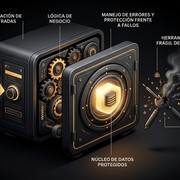

*Figura E02. Loop ReAct minimo con estado, accion, observacion y cierre.*

## Proposito

Este notebook muestra el esqueleto minimo de un agente ReAct.

La este notebook define ReAct como:

```text
Reasoning + Acting
```

Y lo representa como:

```text
Thought -> Action -> Observation -> Thought -> Action -> Observation -> Final Answer
```

En este ejercicio no usamos un LLM para decidir. Usamos reglas simples para que puedas ver claramente el mecanismo del agente.


## Definiciones clave

| Concepto | Definicion | En este notebook |
|---|---|---|
| State | Memoria de corto plazo del agente. | `state` guarda `customer` y `balance`. |
| Action | Tool que el agente decide ejecutar. | `get_customer`, `get_balance`, `finalize`. |
| Observation | Resultado devuelto por una tool. | Diccionarios con `success` y datos. |
| Trace | Historial auditable de pasos. | Lista con `step`, `action`, `observation`. |
| Stop condition | Regla para terminar. | `finalize` o `max_steps reached`. |
| max_steps | Limite de seguridad. | Evita loops infinitos. |

Idea central: un agente no deberia actuar sin limite. Debe saber cuando responder y cuando fallar de forma controlada.


## C?mo encaja este notebook en la diferencia Pipeline vs AI Agent

Un pipeline ejecutaria una secuencia fija de funciones. Este notebook muestra el patron de un **AI Agent** porque la proxima accion depende del **state**.

Las tools son simples y mockeadas, pero cumplen el mismo rol conceptual que una custom tool real:

- `get_customer`: obtiene un dato que faltaba;
- `get_balance`: obtiene otro dato necesario;
- `finalize`: construye la respuesta cuando el estado ya esta completo.

El grounding aca no viene de una API externa, sino de observaciones explicitas producidas por tools. Por eso el `trace` permite revisar como se llego a la respuesta.


## Paso 1 - Tools disponibles

Estas tools simulan un flujo de cobranza:

1. obtener cliente;
2. obtener balance;
3. finalizar con una respuesta.

Cada tool recibe `state`, porque el resultado de una accion puede depender de lo que el agente ya sabe.


In [ ]:
TOOLS = {
    "get_customer": lambda state: {"success": True, "customer": "Acme"},
    "get_balance": lambda state: {"success": True, "balance": 1200},
    "finalize": lambda state: {
        "success": True,
        "answer": f"{state['customer']} owes USD {state['balance']}",
    },
}


## Paso 2 - TODOs 1 a 3: elegir la proxima accion

Completa `choose_action(state)`.

Esta funcion representa la policy del agente: mira el estado y decide que hacer.

Reglas:

- si falta `customer`, la proxima accion es `get_customer`;
- si falta `balance`, la proxima accion es `get_balance`;
- si ya esta todo, la proxima accion es `finalize`.

Esto diferencia a un agente de un pipeline: el agente decide según estado.


In [ ]:
def choose_action(state):
    # TODO 1: si falta customer -> get_customer
    # TODO 2: si falta balance -> get_balance
    # TODO 3: si ya esta todo -> finalize
    pass


### Anatomia del loop ReAct

El loop ReAct se puede describir como:

```text
Thought: "Para responder esto, primero necesito X."
Action: llamar la tool que recupera o calcula X.
Observation: leer el resultado de la tool.
Thought: "Dado este resultado, ahora necesito Y."
Action: llamar otra tool.
Observation: leer el resultado.
Thought: "Ya tengo suficiente informacion."
Final Answer: responder al usuario.
```

La diferencia con un pipeline es que **cada accion depende de la observacion anterior**.

En este ejercicio, `choose_action(state)` implementa exactamente esa logica:

- si falta `customer` -> obtener cliente primero,
- si falta `balance` -> obtener balance despues,
- si ya hay todo -> finalizar.

### Por qu? `max_steps` es obligatorio en producci?n

> "Nunca conviene dejar un agente ejecutando pasos infinitos."

Si hay un bug en `choose_action` o las tools nunca devuelven los datos esperados,
el agente podria correr para siempre gastando recursos.

`max_steps = 5` es una red de seguridad que garantiza que el sistema siempre termina.


## Paso 3 - TODO 4: implementar el loop ReAct

Completa `run_agent(max_steps=5)`.

El loop debe hacer esto:

1. elegir accion con `choose_action(state)`;
2. ejecutar la tool;
3. guardar la observacion en `trace`;
4. si la tool falla, devolver error seguro;
5. actualizar `state` con la observacion;
6. si la accion fue `finalize`, devolver respuesta;
7. si se agotan los pasos, devolver `max_steps reached`.

Este es el nucleo operativo de un agente.


In [ ]:
def run_agent(max_steps=5):
    state = {}
    trace = []

    # TODO 4: implementar loop ReAct completo
    pass


### Que verifican estos checks y por que importan

El primer check verifica el **camino feliz**: el agente obtiene todos los datos
y devuelve la respuesta correcta.

El segúndo check verifica el **comportamiento de seguridad**: si los pasos se agotan,
el agente debe fallar de forma controlada, no con una excepcion sin manejar.

Un agente que:

- devuelve un error claro cuando se agota -> es predecible y auditable,
- lanza una excepcion sin capturar -> rompe el sistema del que es parte.

Regla práctica:

> "Si una tool falla, el agente no deberia inventar. Deberia decir que no pudo
> obtener el dato."

Lo mismo aplica al limite de pasos: si se agotaron, reportar el problema, no inventar.


## Paso 4 - Ejecutar checks

Los checks validan dos cosas:

- el orden correcto de acciones: `get_customer`, `get_balance`, `finalize`;
- el limite de seguridad `max_steps`.

Si el segúndo check falla, el agente podria entrar en loops infinitos en un caso real.


In [ ]:
def run_checks():
    result = run_agent()
    assert result["success"] is True
    assert result["answer"] == "Acme owes USD 1200"
    assert [step["action"] for step in result["trace"]] == [
        "get_customer",
        "get_balance",
        "finalize",
    ]

    limited = run_agent(max_steps=1)
    assert limited["success"] is False
    assert "max_steps" in limited["error"]

    print("M3L1 E02 Starter checks passed")


run_checks()


## Cierre conceptual

Diferencia entre conceptos:

| Elemento | Para que sirve |
|---|---|
| `state` | Guarda lo que el agente sabe ahora. |
| `trace` | Guarda lo que el agente hizo y observo. |
| `choose_action()` | Decide la accion a tomar. |
| `TOOLS[action]` | Ejecuta la accion. |
| `max_steps` | Protege contra loops infinitos. |

Este ejercicio es pequeno, pero contiene la anatomia del agente del hands-on principal.
